In [1]:
# 对前面所有代码的整合
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 读取数据
data_000001 = pd.read_excel('./Data_return/data_000001.xlsx')
data_399001 = pd.read_excel('./Data_return/data_339001.xlsx')
data_000600 = pd.read_excel('./Data_return/data_000600.xlsx')
data_600600 = pd.read_excel('./Data_return/data_600600.xlsx')

In [3]:
def EXP7_jianyan(stock_data):
    # 使用arch模型进行检验
    data = stock_data['return'].copy()
    data = data[(data >= -0.12) & (data <= 0.12)]
    archModel = arch_model(data, mean='Zero', vol='ARCH', p=1, q=0)
    res_arch = archModel.fit()
    print('ARCH(1)模型的拟合结果为：')
    print(res_arch.summary())
    # 使用garch（1，1）模型检验
    am_garch = arch_model(data, mean='constant', vol='garch', p=1, q=1, dist='normal') 
    res_garch = am_garch.fit()
    print('GARCH(1,1)模型的拟合结果为：')
    print(res_garch.summary())
    # 估计EGARCH（1，1）模型
    am_egarch = arch_model(data*100, mean='constant', vol='egarch', p=1, q=1, o=1)
    res_egarch = am_egarch.fit()
    print('EGARCH(1,1)模型的拟合结果为：')
    print(res_egarch.summary())
    # 画图
    # 模拟arch模型
    sim_arch = arch_model(None, mean='Zero', vol='ARCH', p=1, q=0)
    # 上面arch拟合出来的参数
    sim_paras_arch = res_arch.params
    sim_arch_data = sim_arch.simulate(sim_paras_arch,len(data))
    plt.plot(sim_arch_data)
    plt.plot(data, label='Original Returns')
    plt.legend(loc='lower left')
    plt.title('Original Returns and Simulated Returns from ARCH(1,1)')
    plt.xlabel('Time')
    plt.ylabel('Return')
    plt.show()
    # 模拟GARCH
    sim_garch = arch_model(None, mean='constant', vol='garch', p=1, q=1, dist='normal') 
    sim_paras_garch = res_garch.params
    sim_garch_data = sim_garch.simulate(sim_paras_garch,len(data))
    plt.plot(sim_garch_data)
    plt.plot(data, label='Original Returns')
    plt.legend(loc='lower left')
    plt.title('Original Returns and Simulated Returns from GARCH(1,1)')
    plt.xlabel('Time')
    plt.ylabel('Return')
    plt.show()
    # 模拟EGARCH（1，1）
    sim_egarch = arch_model(None, mean='constant', vol='egarch', p=1, q=1, o=1)
    sim_paras_egarch = res_egarch.params
    sim_egarch_data = sim_egarch.simulate(sim_paras_egarch,len(data))
    sim_egarch_data = sim_egarch_data / 100
    plt.plot(sim_egarch_data)
    plt.plot(data, label='Original Returns')
    plt.legend(loc='lower left')
    plt.title('Original Returns and Simulated Returns from EGARCH(1,1)')
    plt.xlabel('Time')
    plt.ylabel('Return')
    plt.show()

Iteration:      1,   Func. Count:      3,   Neg. LLF: -14143.287978720296
Optimization terminated successfully    (Exit mode 0)
            Current function value: -14143.28797799764
            Iterations: 5
            Function evaluations: 3
            Gradient evaluations: 1
ARCH(1)模型的拟合结果为：
                        Zero Mean - ARCH Model Results                        
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                14143.3
Distribution:                  Normal   AIC:                          -28282.6
Method:            Maximum Likelihood   BIC:                          -28269.5
                                        No. Observations:                 5088
Date:                Sun, Jun 16 2024   Df Residuals:                     5088
Time:                        13:23:29   Df Model:                     

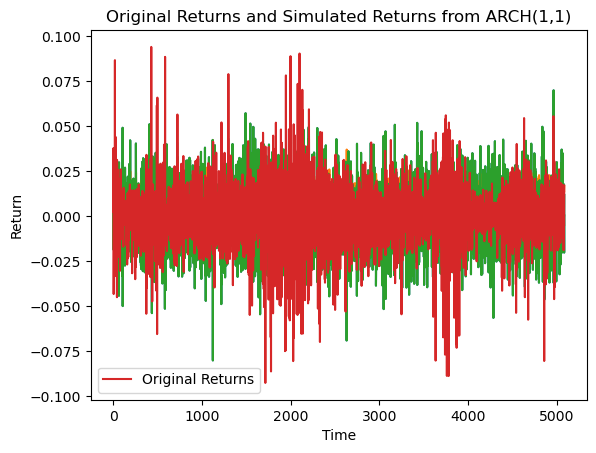

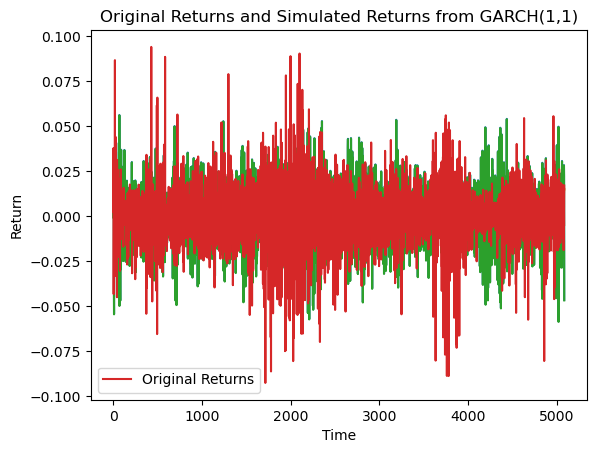

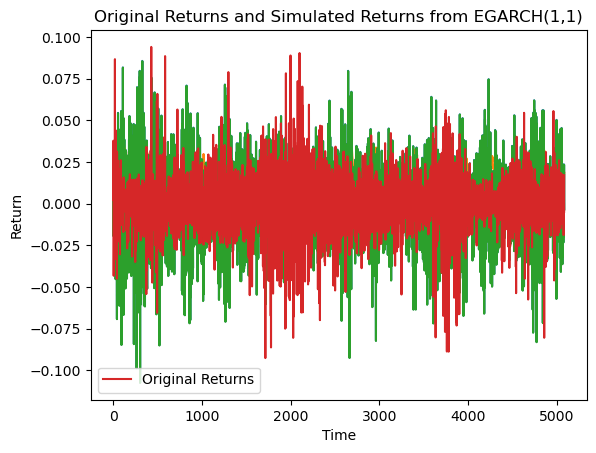

In [4]:
EXP7_jianyan(data_000001)